Dataset Shape: (801, 20532)

First 5 rows:
     Unnamed: 0  gene_0    gene_1    gene_2    gene_3     gene_4
0      sample_0     0.0  2.017209  3.265527  5.478487  10.431999
1      sample_1     0.0  0.592732  1.588421  7.586157   9.623011
2      sample_2     0.0  3.511759  4.327199  6.881787   9.870730
3      sample_3     0.0  3.663618  4.507649  6.659068  10.196184
4      sample_4     0.0  2.655741  2.821547  6.539454   9.738265
..          ...     ...       ...       ...       ...        ...
796  sample_796     0.0  1.865642  2.718197  7.350099  10.006003
797  sample_797     0.0  3.942955  4.453807  6.346597  10.056868
798  sample_798     0.0  3.249582  3.707492  8.185901   9.504082
799  sample_799     0.0  2.590339  2.787976  7.318624   9.987136
800  sample_800     0.0  2.325242  3.805932  6.530246   9.560367

[801 rows x 6 columns]

After Transposing:
Unnamed: 0   sample_0  sample_1  sample_2   sample_3  sample_4  sample_5  \
gene_0       0.000000  0.000000  0.000000   0.000000  0.0

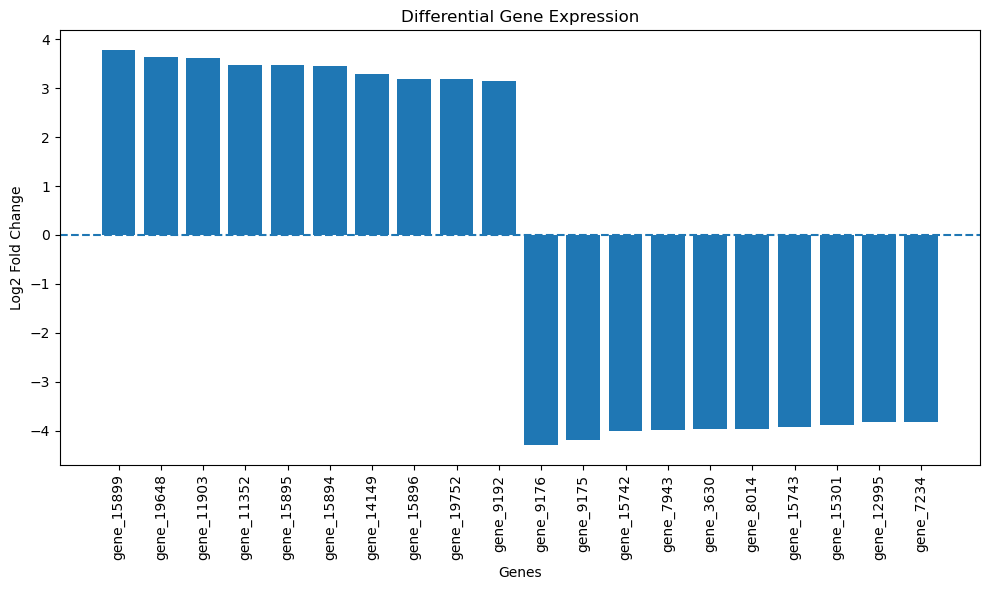

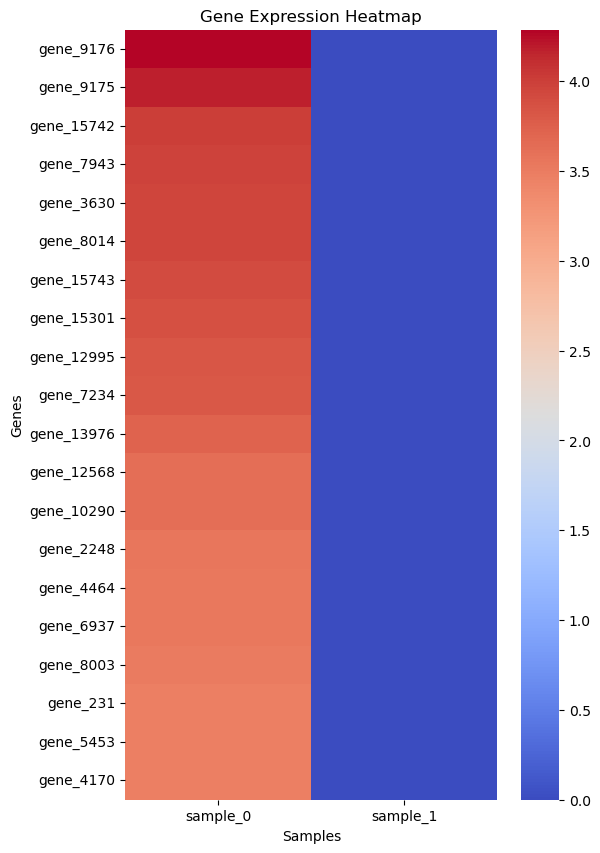

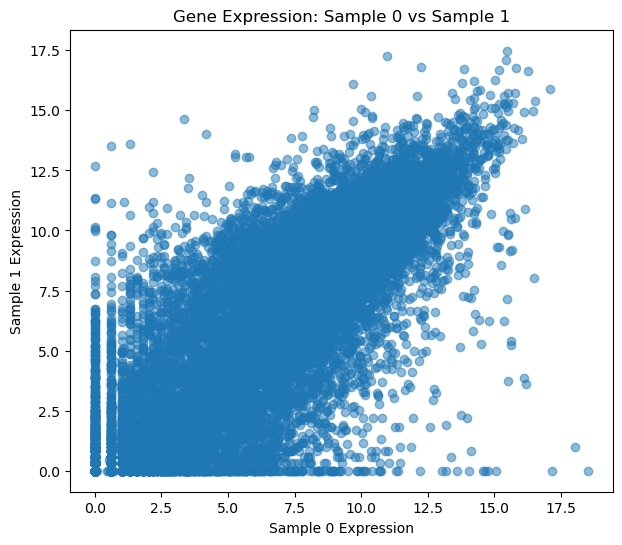

C:\Users\Nistha\AppData\Local\Temp\ipykernel_24160\1631395865.py:203: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deg["Function"] = "Unknown / Not provided"



Results saved to differentially_expressed_genes.csv
Report saved to RNA_Seq_Analysis_Report.txt


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("rna_seq_data.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.iloc[:, :6])

df = df.set_index(df.columns[0])

data = df.T

print("\nAfter Transposing:")
print(data.head())

data = data.fillna(0)

print("\nMissing values:", data.isnull().sum().sum())


sample_0 = data["sample_0"]
sample_1 = data["sample_1"]


data["Fold_Change"] = (
    (sample_1 + 1) /
    (sample_0 + 1)
)

data["Log2_Fold_Change"] = np.log2(
    data["Fold_Change"]
)

data["DEG"] = (
    data["Log2_Fold_Change"].abs() >= 1
)

deg = data[data["DEG"]]

print("\nNumber of Differentially Expressed Genes:",
      len(deg))


upregulated = deg[
    deg["Log2_Fold_Change"] >= 1
]

downregulated = deg[
    deg["Log2_Fold_Change"] <= -1
]

print("Upregulated:", len(upregulated))
print("Downregulated:", len(downregulated))


top_genes = deg.sort_values(
    "Log2_Fold_Change",
    ascending=False
).head(10)

print("\nTop Upregulated Genes:")
print(
    top_genes[
        ["sample_0",
         "sample_1",
         "Log2_Fold_Change"]
    ]
)

top_down = deg.sort_values(
    "Log2_Fold_Change"
).head(10)

print("\nTop Downregulated Genes:")
print(
    top_down[
        ["sample_0",
         "sample_1",
         "Log2_Fold_Change"]
    ]
)


top_plot = pd.concat([
    top_genes,
    top_down
])

plt.figure(figsize=(10, 6))

plt.bar(
    top_plot.index,
    top_plot["Log2_Fold_Change"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Differential Gene Expression")
plt.xlabel("Genes")
plt.ylabel("Log2 Fold Change")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

heatmap_genes = deg.sort_values(
    "Log2_Fold_Change"
).head(20)

heatmap_data = heatmap_genes[
    ["sample_0", "sample_1"]
]

plt.figure(figsize=(6, 10))

sns.heatmap(
    np.log2(heatmap_data + 1),
    cmap="coolwarm"
)

plt.title("Gene Expression Heatmap")
plt.xlabel("Samples")
plt.ylabel("Genes")

plt.show()

plt.figure(figsize=(7, 6))

plt.scatter(
    sample_0,
    sample_1,
    alpha=0.5
)

plt.xlabel("Sample 0 Expression")
plt.ylabel("Sample 1 Expression")

plt.title("Gene Expression: Sample 0 vs Sample 1")

plt.show()

deg["Function"] = "Unknown / Not provided"

deg.to_csv(
    "differentially_expressed_genes.csv"
)

with open(
    "RNA_Seq_Analysis_Report.txt",
    "w"
) as f:

    f.write("RNA-SEQ DATA ANALYSIS REPORT\n")
    f.write("============================\n\n")

    f.write(
        f"Total genes analyzed: {len(data)}\n"
    )

    f.write(
        f"Differentially expressed genes: "
        f"{len(deg)}\n"
    )

    f.write(
        f"Upregulated genes: "
        f"{len(upregulated)}\n"
    )

    f.write(
        f"Downregulated genes: "
        f"{len(downregulated)}\n\n"
    )

    f.write(
        "Top Differentially Expressed Genes\n"
    )
    f.write(
        "-----------------------------------\n"
    )

    for gene in deg.sort_values(
        "Log2_Fold_Change",
        ascending=False
    ).head(10).index:

        fc = data.loc[
            gene,
            "Log2_Fold_Change"
        ]

        f.write(
            f"{gene}: "
            f"Log2 Fold Change = {fc:.2f}\n"
        )

    f.write("\nBiological Interpretation\n")
    f.write("--------------------------\n")

    f.write(
        "Genes with positive Log2 Fold Change "
        "show higher expression in sample_1 "
        "compared with sample_0. Genes with "
        "negative Log2 Fold Change show lower "
        "expression in sample_1.\n\n"
    )

    f.write(
        "The dataset contains artificial gene "
        "identifiers (gene_0, gene_1, etc.), "
        "so specific functional annotations "
        "cannot be assigned without an external "
        "gene annotation database.\n"
    )

print(
    "\nResults saved to "
    "differentially_expressed_genes.csv"
)

print(
    "Report saved to "
    "RNA_Seq_Analysis_Report.txt"
)